In [2]:
import time

import matplotlib.pyplot as plt
import numpy as np
from tqdm import tqdm

from enc_func import Dec, Enc_state, Enc_t, EncryptionConfig, Mod, Params, Seret_key
from FGH import FGHConfig, LQRConfig, PlantConfig, float_to_object_int, observability_matrix, prepare_simulation_data


### Paper-aligned notation

- `Delta`: LWE error bound for the encryption noise term.
- `q = pL - 31 = 2**109 - 31`: prime modulus used for all arithmetic over $\mathbb{Z}_q$.
- `L = 2**44`: message-scaling factor used in the modified LWE encryption.
- `s_1`: scale factor in equation (9) for quantizing the observer matrices.
- `s_2`: scale factor in equation (10) for quantizing the stacked signal $v(k) = [u(k); y(k)]$.
- `n, m, p`: plant state, input, and output dimensions.
- `l = \sum_i l_i`: total dimension of the stacked partial-observer state.
- `l_max = \max_i l_i`: largest single-sensor observability index.


In [5]:
DELTA = 19.2
s_1 = 1e-5
s_2 = 1e-5
iter_count = 10

# The implementation stores the reciprocals of the scale factors as integer multipliers.
s_1_inv = int(round(1 / s_1))
s_2_inv = int(round(1 / s_2))

ENC_CONFIG = EncryptionConfig(p=2**65, L=2**44, r=DELTA, N=2**12, q_offset=31)
FGH_CONFIG = FGHConfig(
    plant=PlantConfig(J1=0.01, J2=0.01, J3=0.01, k1=1.37, k2=1.37, b1=0.007, b2=0.007, b3=0.007, Ts=0.1),
    lqr=LQRConfig(Q_diag=(1.0, 1.0, 1.0, 1.0, 1.0, 1.0), R_diag=(1.0,)),
)

preview_env = Params(ENC_CONFIG)
preview_data = prepare_simulation_data(preview_env, s_quant=s_1_inv, config=FGH_CONFIG)
preview_model = preview_data.model
A_preview = preview_model.A
B_preview = preview_model.B.reshape(-1, 1)
C_preview = preview_model.C

n = A_preview.shape[0]
m = B_preview.shape[1]
p = C_preview.shape[0]
l = preview_model.F_bar.shape[0]
l_i = [int(np.linalg.matrix_rank(observability_matrix(A_preview, C_preview[i : i + 1]))) for i in range(p)]
l_max = max(l_i)
n_r = preview_data.offline["H_bar"].shape[0]
q = preview_env.q

print("Parameters")
print(f"Delta = {DELTA}")
print(f"L = 2**44 = {ENC_CONFIG.L}")
print(f"N = 2**12 = {ENC_CONFIG.N}")
print(f"q = pL - {ENC_CONFIG.q_offset} = {q}")
print(f"s_1 = {s_1:.1e}  ->  1/s_1 = {s_1_inv}")
print(f"s_2 = {s_2:.1e}  ->  1/s_2 = {s_2_inv}")
print()
print("Three-inertia model dimensions")
print(f"n = {n}, m = {m}, p = {p}, l = {l}, l_max = {l_max}, n_r = {n_r}")
print(f"l_i = {l_i}")
print()
with np.printoptions(precision=4, suppress=True):
    print("A =")
    print(A_preview)
    print()
    print("B =")
    print(B_preview)
    print()
    print("C =")
    print(C_preview)


Parameters
Delta = 19.2
L = 2**44 = 17592186044416
N = 2**12 = 4096
q = pL - 31 = 649037107316853453566312041152481
s_1 = 1.0e-05  ->  1/s_1 = 100000
s_2 = 1.0e-05  ->  1/s_2 = 100000

Three-inertia model dimensions
n = 6, m = 1, p = 5, l = 24, l_max = 6, n_r = 60
l_i = [6, 4, 6, 4, 4]

A =
[[  0.4666   0.0773   0.4701   0.0179   0.0632   0.0013]
 [ -8.1348   0.4125   5.8588   0.4576   2.276    0.0623]
 [  0.4701   0.0179   0.0597   0.0607   0.4701   0.0179]
 [  5.8588   0.4576 -11.7176   0.0172   5.8588   0.4576]
 [  0.0632   0.0013   0.4701   0.0179   0.4666   0.0773]
 [  2.276    0.0623   5.8588   0.4576  -8.1348   0.4125]]

B =
[[0.4378]
 [7.7317]
 [0.0485]
 [1.7938]
 [0.0023]
 [0.1325]]

C =
[[ 1.  0.  0.  0.  0.  0.]
 [ 0.  0.  1.  0.  0.  0.]
 [ 0.  0.  0.  0.  1.  0.]
 [ 1.  0. -1.  0.  0.  0.]
 [ 0.  0.  1.  0. -1.  0.]]


In [ ]:
# Piecewise attack profile applied to sensor 3 during the run.
def attack_value(k, start, total):
    if k < start:
        return 0.0
    crit = (k - start) / total
    if crit < 0.1:
        return 1.0
    if 0.35 <= crit < 0.4:
        return -1.0
    return 0.0


# Build the plant, observer, and scaling data shared by the encrypted simulation.
def build_simulation_context():
    env = Params(ENC_CONFIG)
    prepared = prepare_simulation_data(env, s_quant=s_1_inv, config=FGH_CONFIG)
    model, offline = prepared.model, prepared.offline

    return {
        "env": env,
        "model": model,
        "offline": offline,
        "A": model.A,
        "B": model.B.reshape(-1, 1),
        "C": model.C,
        "K": model.K.reshape(1, -1),
        "state_scale": env.L * s_1_inv * s_1_inv * s_2_inv,
        "residue_scale": s_1_inv * s_1_inv * s_2_inv,
    }


# Initialize one encrypted observer state for each residual channel.
def initialize_encrypted_observers(env, offline, sk, state_scale):
    F_bar, G_bar, H_bar, Phi_pinv_bar = (offline[key] for key in ("F_bar", "G_bar", "H_bar", "Phi_pinv_bar"))
    T1_all, T2_all, V2_all = (offline[key] for key in ("T1_all", "T2_all", "V2_all"))
    S_xi_all, S_v_all, Psi_all, Sigma_all, Sigma_pinv_all = (
        offline[key] for key in ("S_xi_all", "S_v_all", "Psi_all", "Sigma_all", "Sigma_pinv_all")
    )

    # Start all observer channels from the same zero quantized state.
    z_hat_bar = np.zeros((l, 1), dtype=int)
    Z_hat_list, b_xi_list = [], []
    for T1_j, T2_j, V2_j in zip(T1_all, T2_all, V2_all):
        # Encrypt the initial state with the channel-specific masking structure.
        Z_hat_j, b_xi_j = Enc_state(z_hat_bar, sk, env, T1_j, T2_j, V2_j)
        Z_hat_list.append(Z_hat_j)
        b_xi_list.append(b_xi_j)

    x_hat_list = [Dec(Mod(Phi_pinv_bar @ Z_hat_list[0], env.q), sk, env) / state_scale]
    channel_terms = [
        (H_bar[j : j + 1, :], S_xi_all[j], S_v_all[j], Psi_all[j], Sigma_all[j], Sigma_pinv_all[j])
        for j in range(n_r)
    ]

    return Phi_pinv_bar, F_bar, G_bar, channel_terms, Z_hat_list, b_xi_list, x_hat_list


# Gather all static data before entering the simulation loop.
context = build_simulation_context()
env = context["env"]
model = context["model"]
offline = context["offline"]
A = context["A"]
B = context["B"]
C = context["C"]
K = context["K"]
state_scale = context["state_scale"]
residue_scale = context["residue_scale"]
sk = Seret_key(env)

# Precompute the encrypted observer states and per-channel update terms.
Phi_pinv_bar, F_bar, G_bar, channel_terms, Z_hat_list, b_xi_list, x_hat_list = initialize_encrypted_observers(
    env, offline, sk, state_scale
)

xp = [np.ones((n, 1), dtype=float)]
attack_start = iter_count // 2
attack_arr = np.zeros(iter_count)
u, y = [], []
residue = np.zeros((iter_count, n_r))
execution_times = []


In [7]:
for k in tqdm(range(iter_count)):
    # Form the nominal plant output and feedback input at time step k.
    t_start = time.perf_counter()
    y_k = C @ xp[-1]
    u_k = (K @ xp[-1]).item()
    v = np.vstack([[[u_k]], y_k])

    # Inject the attack into sensor 3 and quantize the stacked signal [u; y].
    attack = attack_value(k, attack_start, iter_count)
    attack_arr[k] = attack
    v[3, 0] += attack
    v_bar = float_to_object_int(v * s_2_inv)

    y.append(y_k)
    u.append(u_k)

    # For each channel, disclose the scalar residual and update the encrypted observer state.
    for j, (H_j, S_xi_j, S_v_j, Psi_j, Sigma_j, Sigma_pinv_j) in enumerate(channel_terms):
        Z_hat_j, b_xi_j = Z_hat_list[j], b_xi_list[j]
        r_bar_j = Mod(Mod(H_j @ Z_hat_j, env.q)[0, 0] * env.invL, env.q)
        residue[k, j] = float(r_bar_j) / residue_scale

        V_j, b_v_j = Enc_t(v_bar, sk, b_xi_j, Sigma_pinv_j, Sigma_j, Psi_j, env)
        Z_hat_list[j] = Mod(F_bar @ Z_hat_j + G_bar @ V_j, env.q)
        b_xi_list[j] = Mod(S_xi_j @ b_xi_j + S_v_j @ b_v_j, env.q)

    # Recover the state estimate from one encrypted observer and propagate the plaintext plant.
    x_hat_list.append(Dec(Mod(Phi_pinv_bar @ Z_hat_list[0], env.q), sk, env) / state_scale)
    xp.append(A @ xp[-1] + B * u_k)
    execution_times.append(time.perf_counter() - t_start)

# Summarize the per-step runtime of the encrypted simulation.
execution_times = np.array(execution_times)
print(f"Iteration time min  : {execution_times.min():.6f} s")
print(f"Iteration time max  : {execution_times.max():.6f} s")
print(f"Iteration time mean : {execution_times.mean():.6f} s")


100%|██████████| 10/10 [01:44<00:00, 10.44s/it]

Iteration time min  : 7.094679 s
Iteration time max  : 15.793692 s
Iteration time mean : 10.441171 s


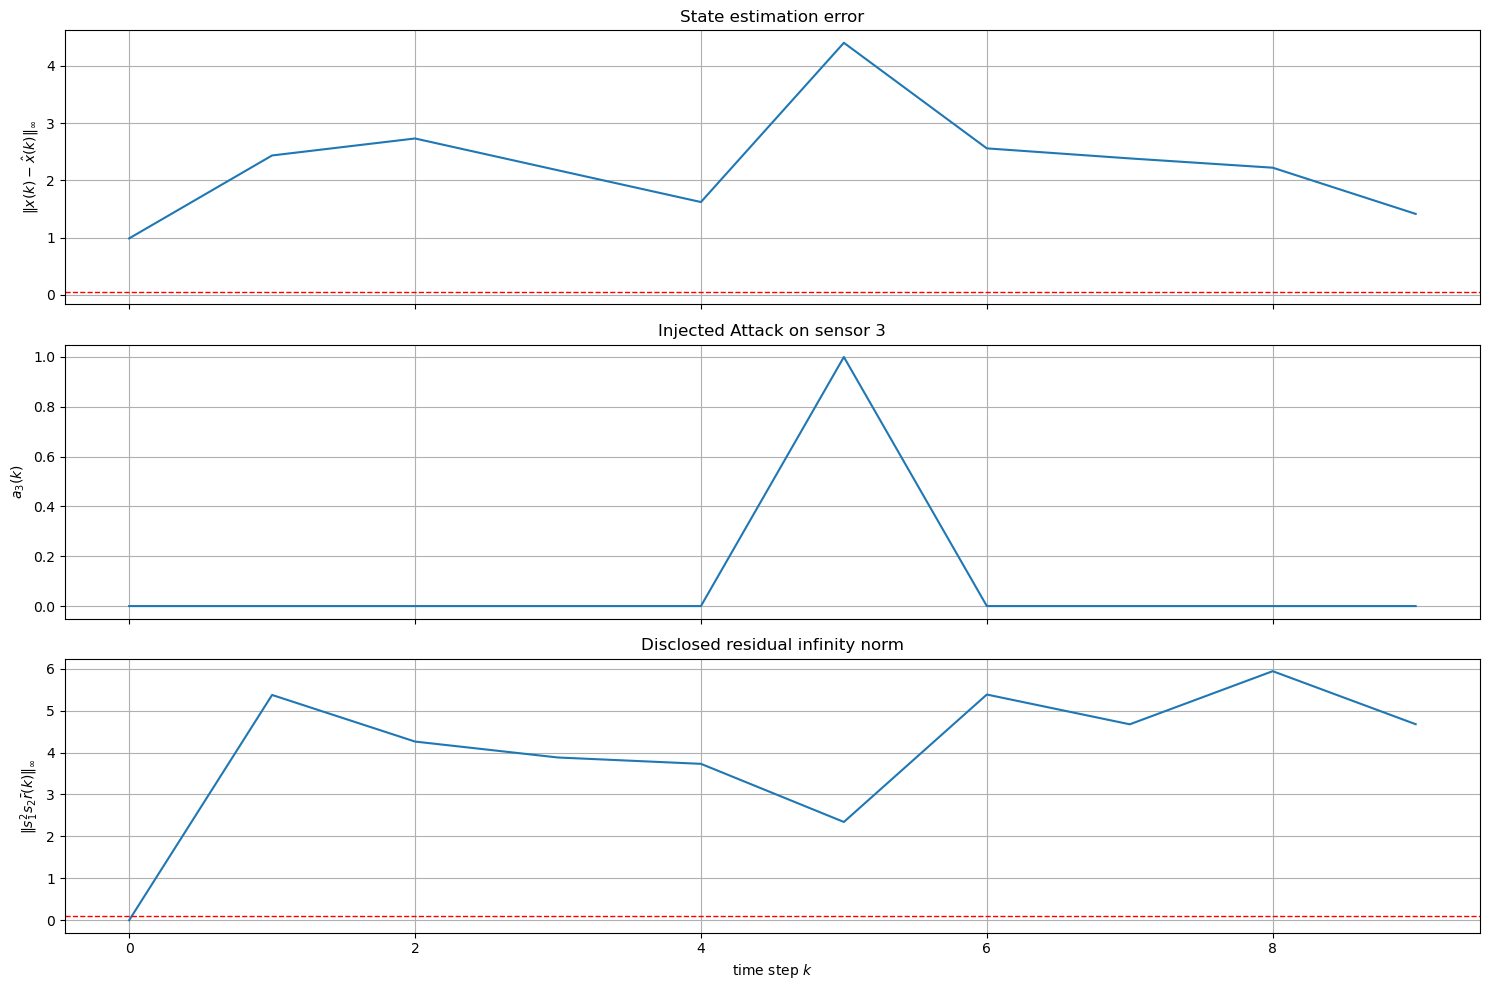

In [9]:
xp_arr = np.hstack(xp)
x_hat_arr = np.hstack(x_hat_list)
t = np.arange(iter_count)

fig, axes = plt.subplots(3, 1, figsize=(15, 10), sharex=True)
axes[0].plot(t, np.max(np.abs(xp_arr[:, 1:] - x_hat_arr[:, 1:]), axis=0))
axes[0].axhline(0.05, color="red", linestyle="--", linewidth=1)
axes[0].grid(True)
axes[0].set_ylabel(r"$\|x(k)-\hat{x}(k)\|_\infty$")
axes[0].set_title("State estimation error")

axes[1].plot(t, attack_arr)
axes[1].grid(True)
axes[1].set_ylabel(r"$a_3(k)$")
axes[1].set_title("Injected Attack on sensor 3")

axes[2].plot(t, np.max(np.abs(residue), axis=1), label=r"$\|s_1^2 s_2\bar{r}(k)\|_\infty$")
axes[2].axhline(0.1, color="red", linestyle="--", linewidth=1)
axes[2].grid(True)
axes[2].set_xlabel(r"time step $k$")
axes[2].set_ylabel(r"$\|s_1^2 s_2\bar{r}(k)\|_\infty$")
axes[2].set_title("Disclosed residual infinity norm")
fig.tight_layout()
plt.show()
